# Custom sources and variability

Any callable returning `[time, y, x, band]` brightness can become a source.
This example defines an evolving ring, visualizes it in physical coordinates,
and then passes the same object unchanged through a ten-year dynamic
microlensing calculation. The source callback is evaluated daily while the
slowly evolving stellar magnification field is generated every 25 days.

## Define and inspect a callable source

The ring amplitude changes coherently here, but a callback may evolve its
size, shape, spectrum, or all three.  The three panels use one logarithmic
normalization and the paper-style physical scale bar.

In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
)
distances = mc.LensingDistances.from_redshifts(0.5, 1.5)
source_fov_uas = 0.80
source_resolution = 129
source_width_m = float(distances.uas_to_source_length(source_fov_uas, dtype=torch.float64))
geometry = mc.SourceGeometry(
    (source_resolution, source_resolution),
    (source_width_m / source_resolution, source_width_m / source_resolution),
    (4800.0, 7500.0), ("blue", "red"),
)

def brightness(times):
    times = torch.as_tensor(times)
    axis_y = torch.linspace(-1.0, 1.0, geometry.shape[0], device=times.device, dtype=times.dtype)[:, None]
    axis_x = torch.linspace(-1.0, 1.0, geometry.shape[1], device=times.device, dtype=times.dtype)[None, :]
    radius = torch.sqrt(axis_x.square() + axis_y.square())
    azimuth = torch.atan2(axis_y, axis_x)
    phase = 2.0 * torch.pi * times[:, None, None] / 600.0
    ring_radius = 0.28 + 0.08 * torch.sin(phase)
    ring = torch.exp(-0.5 * ((radius[None] - ring_radius) / 0.055).square())
    hotspot = 1.0 + 0.35 * torch.cos(azimuth[None] - phase) * torch.exp(-0.5 * (radius[None] / 0.55).square())
    envelope = 0.85 + 0.15 * torch.cos(phase)
    image = envelope * ring * hotspot
    return torch.stack((image, 0.75 * image.pow(0.9)), dim=-1)

source = mc.CallableSource(brightness, geometry, name="evolving asymmetric ring")


{'type': 'callable', 'name': 'evolving asymmetric ring', 'is_time_static': False}


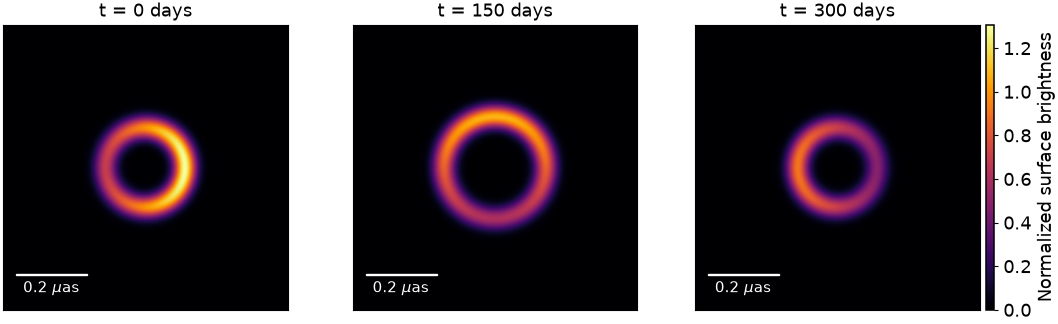

In [2]:
display_times = (0.0, 150.0, 300.0)
images = source.brightness(display_times).detach().cpu().numpy()[..., 0]
vmax = float(images.max())
figure, axes = plt.subplots(1, 3, figsize=(11.4, 3.45))
artist = None
for ax, time, image_values in zip(axes, display_times, images, strict=True):
    artist = ax.imshow(
        image_values, origin="lower",
        extent=(-0.5 * source_fov_uas, 0.5 * source_fov_uas) * 2,
        cmap="inferno", vmin=0.0, vmax=vmax, interpolation="bilinear",
    )
    ax.set_title(f"t = {time:.0f} days")
    mcp.add_scale_bar(ax, 0.2, label=r"0.2 $\mu$as", color="white")
    mcp.hide_image_axes(ax)
mcp.panel_colorbar(figure, axes[-1], artist, label="Normalized surface brightness", size="3%")
figure.tight_layout()
print(source.metadata())


## Use the custom source in a dynamic light curve

No solver-specific adapter is required. The main curve evaluates the custom
source daily using two bracketing map--source contractions from the 25-day
map sequence. Interpolated daily maps are never materialized. A separate
three-epoch call demonstrates batching two source trajectories without
duplicating its streamed maps.
The plotted magnitude uses an explicit mock zero point rather than a relative-
magnitude convention.

Dynamic maps: 147 daily custom-source samples: 3651
Batched light curves: ('centered ring', 'offset ring')


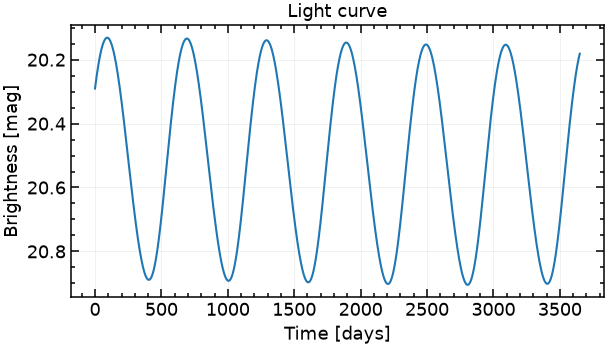

In [3]:
field = mc.PointMassField(
    x_uas=torch.tensor([-1.2, -0.25, 0.55, 1.15]),
    y_uas=torch.tensor([0.65, -0.75, 0.30, -0.15]),
    einstein_radius_uas=torch.tensor([0.30, 0.22, 0.26, 0.20]),
    velocity_x_uas_per_day=torch.tensor([1.2e-4, -0.8e-4, 0.6e-4, -0.5e-4]),
    velocity_y_uas_per_day=torch.tensor([-0.4e-4, 0.7e-4, -0.9e-4, 0.5e-4]),
)
source_grid = mc.PlaneGrid((1024 if use_cuda else 256,) * 2, (1.05 * source_fov_uas,) * 2)
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(0.25, 0.12), distances=distances, stars=field, source=source,
    source_grid=source_grid, lens_region=mc.PlaneRegion((6.0, 6.0)),
    duration_days=3650.0, runtime=runtime_config,
)
method = mc.production_ipm_config(
    dynamic=True, rays=10_000_000 if use_cuda else 262_144,
    cell_chunk_size=524_288 if use_cuda else 65_536,
)
schedule = mc.production_dynamic_config(light_curve_batch_size=2)
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
requests = (
    mc.LightCurveRequest(source, distances, name='centered ring'),
    mc.LightCurveRequest(
        source, distances, name='offset ring',
        trajectory=mc.LinearTrajectory(
            initial_position_uas=(0.01 * source_fov_uas, -0.01 * source_fov_uas)
        ),
    ),
)
curve = system.multirate_light_curve(
    map_times.tolist(), flux_times.tolist(), method=method, schedule=schedule,
)
print('Dynamic maps:', len(map_times), 'daily custom-source samples:', len(flux_times))
# A tiny, separate call demonstrates batching multiple trajectories without
# repeating the expensive ten-year production calculation.
batch_demo = system.light_curves(
    (0.0, 25.0, 50.0), requests,
    method=method, schedule=schedule,
)
print('Batched light curves:', tuple(item.metadata['request_name'] for item in batch_demo))
blue = curve.flux[:, 0]
zero_point_flux = float(mc.zero_point_flux_for_magnitude(torch.median(blue), 20.5))
figure, ax = mcp.plot_light_curve(
    curve, bands=("blue",), magnitude=True, normalize=False,
    zero_point_flux={"blue": zero_point_flux, "red": zero_point_flux},
)
ax.set_ylabel("Brightness [mag]")
if ax.get_legend() is not None:
    ax.get_legend().remove()
figure.tight_layout()
